In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/Users/sidkumar/Documents/Work /Artificial Intelligence/Deep Learning/DATA/cancer_classification.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
mean radius                569 non-null float64
mean texture               569 non-null float64
mean perimeter             569 non-null float64
mean area                  569 non-null float64
mean smoothness            569 non-null float64
mean compactness           569 non-null float64
mean concavity             569 non-null float64
mean concave points        569 non-null float64
mean symmetry              569 non-null float64
mean fractal dimension     569 non-null float64
radius error               569 non-null float64
texture error              569 non-null float64
perimeter error            569 non-null float64
area error                 569 non-null float64
smoothness error           569 non-null float64
compactness error          569 non-null float64
concavity error            569 non-null float64
concave points error       569 non-null float64
symmetry error             569 

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

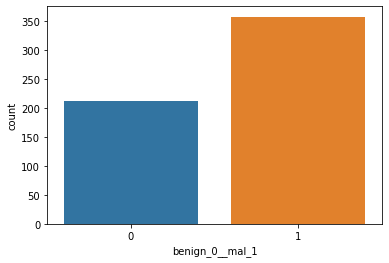

In [6]:
sns.countplot(x='benign_0__mal_1',data=df)

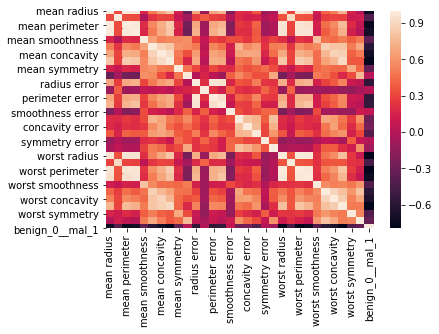

In [7]:
sns.heatmap(df.corr())

In [8]:
df.corr()['benign_0__mal_1'].sort_values()

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

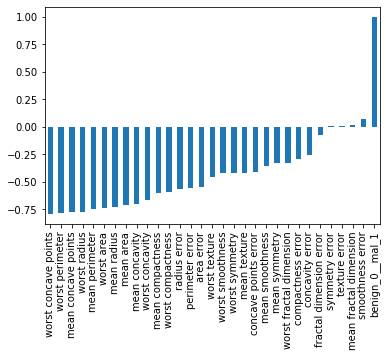

In [9]:
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')

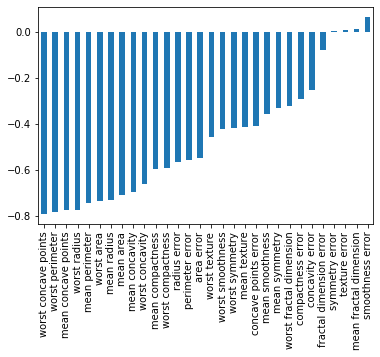

In [10]:
df.corr()['benign_0__mal_1'][:-1].sort_values().plot(kind='bar')

In [11]:
X = df.drop('benign_0__mal_1',axis=1).values
y = df['benign_0__mal_1'].values

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=101)

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler = MinMaxScaler()

In [16]:
scaler.fit(X_train)

MinMaxScaler(copy=True, feature_range=(0, 1))

In [17]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Dropout

/Users/sidkumar/opt/anaconda3/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/Users/sidkumar/opt/anaconda3/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/Users/sidkumar/opt/anaconda3/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/Users/sidkumar/opt/anaconda3/lib/python3.7/site-packages/ten

In [19]:
X_train.shape

(426, 30)

In [20]:
model = Sequential()

# https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw

model.add(Dense(units=30,activation='relu'))

model.add(Dense(units=15,activation='relu'))


model.add(Dense(units=1,activation='sigmoid'))

# For a binary classification problem
model.compile(loss='binary_crossentropy', optimizer='adam')

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [21]:
# https://stats.stackexchange.com/questions/164876/tradeoff-batch-size-vs-number-of-iterations-to-train-a-neural-network
# https://datascience.stackexchange.com/questions/18414/are-there-any-rules-for-choosing-the-size-of-a-mini-batch

model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1
          )

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Train on 426 samples, validate on 143 samples
Epoch 1/600
426/426 [==============================] - 1s 3ms/sample - loss: 0.6930 - val_loss: 0.6724
Epoch 2/600
426/426 [==============================] - 0s 121us/sample - loss: 0.6565 - val_loss: 0.6402
Epoch 3/600
426/426 [==============================] - 0s 118us/sample - loss: 0.6222 - val_loss: 0.6072
Epoch 4/600
426/426 [==============================] - 0s 124us/sample - loss: 0.5860 - val_loss: 0.5707
Epoch 5/600
426/426 [==============================] - 0s 139us/sample - loss: 0.5465 - val_loss: 0.5291
Epoch 6/600
426/426 [==============================] - 0s 121us/sample - loss: 0.5034 - val_loss: 0.4830
Epoch 7/600
426/426 [==============================] - 0s 141us/sample - loss: 0.4566 - val_loss: 0.4341
Epoch 8/600
426/426 [==============================] - 0s 124us/sample - loss: 0.4100 - val_loss: 0.3848
Epoch 9/600
426/426 [=

426/426 [==============================] - 0s 137us/sample - loss: 0.0546 - val_loss: 0.1112
Epoch 75/600
426/426 [==============================] - 0s 126us/sample - loss: 0.0543 - val_loss: 0.1082
Epoch 76/600
426/426 [==============================] - 0s 114us/sample - loss: 0.0542 - val_loss: 0.1090
Epoch 77/600
426/426 [==============================] - 0s 114us/sample - loss: 0.0516 - val_loss: 0.1072
Epoch 78/600
426/426 [==============================] - 0s 108us/sample - loss: 0.0547 - val_loss: 0.1067
Epoch 79/600
426/426 [==============================] - 0s 110us/sample - loss: 0.0510 - val_loss: 0.1075
Epoch 80/600
426/426 [==============================] - 0s 121us/sample - loss: 0.0512 - val_loss: 0.1080
Epoch 81/600
426/426 [==============================] - 0s 114us/sample - loss: 0.0503 - val_loss: 0.1076
Epoch 82/600
426/426 [==============================] - 0s 118us/sample - loss: 0.0542 - val_loss: 0.1077
Epoch 83/600
426/426 [==============================] - 0s 

Epoch 151/600
426/426 [==============================] - 0s 121us/sample - loss: 0.0373 - val_loss: 0.1161
Epoch 152/600
426/426 [==============================] - 0s 114us/sample - loss: 0.0363 - val_loss: 0.1166
Epoch 153/600
426/426 [==============================] - 0s 123us/sample - loss: 0.0379 - val_loss: 0.1177
Epoch 154/600
426/426 [==============================] - 0s 115us/sample - loss: 0.0381 - val_loss: 0.1202
Epoch 155/600
426/426 [==============================] - 0s 119us/sample - loss: 0.0350 - val_loss: 0.1189
Epoch 156/600
426/426 [==============================] - 0s 116us/sample - loss: 0.0365 - val_loss: 0.1213
Epoch 157/600
426/426 [==============================] - 0s 115us/sample - loss: 0.0349 - val_loss: 0.1182
Epoch 158/600
426/426 [==============================] - 0s 117us/sample - loss: 0.0365 - val_loss: 0.1256
Epoch 159/600
426/426 [==============================] - 0s 115us/sample - loss: 0.0376 - val_loss: 0.1119
Epoch 160/600
426/426 [==============

426/426 [==============================] - 0s 116us/sample - loss: 0.0265 - val_loss: 0.1193
Epoch 228/600
426/426 [==============================] - 0s 134us/sample - loss: 0.0321 - val_loss: 0.1473
Epoch 229/600
426/426 [==============================] - 0s 116us/sample - loss: 0.0253 - val_loss: 0.1219
Epoch 230/600
426/426 [==============================] - 0s 112us/sample - loss: 0.0250 - val_loss: 0.1234
Epoch 231/600
426/426 [==============================] - 0s 115us/sample - loss: 0.0245 - val_loss: 0.1324
Epoch 232/600
426/426 [==============================] - 0s 116us/sample - loss: 0.0248 - val_loss: 0.1218
Epoch 233/600
426/426 [==============================] - 0s 117us/sample - loss: 0.0247 - val_loss: 0.1338
Epoch 234/600
426/426 [==============================] - 0s 119us/sample - loss: 0.0247 - val_loss: 0.1247
Epoch 235/600
426/426 [==============================] - 0s 108us/sample - loss: 0.0235 - val_loss: 0.1232
Epoch 236/600
426/426 [============================

426/426 [==============================] - 0s 121us/sample - loss: 0.0165 - val_loss: 0.1353
Epoch 304/600
426/426 [==============================] - 0s 123us/sample - loss: 0.0165 - val_loss: 0.1396
Epoch 305/600
426/426 [==============================] - 0s 110us/sample - loss: 0.0168 - val_loss: 0.1442
Epoch 306/600
426/426 [==============================] - 0s 113us/sample - loss: 0.0165 - val_loss: 0.1392
Epoch 307/600
426/426 [==============================] - 0s 108us/sample - loss: 0.0171 - val_loss: 0.1375
Epoch 308/600
426/426 [==============================] - 0s 117us/sample - loss: 0.0168 - val_loss: 0.1439
Epoch 309/600
426/426 [==============================] - 0s 118us/sample - loss: 0.0170 - val_loss: 0.1442
Epoch 310/600
426/426 [==============================] - 0s 121us/sample - loss: 0.0169 - val_loss: 0.1399
Epoch 311/600
426/426 [==============================] - 0s 112us/sample - loss: 0.0177 - val_loss: 0.1494
Epoch 312/600
426/426 [============================

426/426 [==============================] - 0s 120us/sample - loss: 0.0127 - val_loss: 0.1499
Epoch 380/600
426/426 [==============================] - 0s 122us/sample - loss: 0.0120 - val_loss: 0.1578
Epoch 381/600
426/426 [==============================] - 0s 112us/sample - loss: 0.0118 - val_loss: 0.1626
Epoch 382/600
426/426 [==============================] - 0s 125us/sample - loss: 0.0122 - val_loss: 0.1510
Epoch 383/600
426/426 [==============================] - 0s 132us/sample - loss: 0.0120 - val_loss: 0.1688
Epoch 384/600
426/426 [==============================] - 0s 114us/sample - loss: 0.0110 - val_loss: 0.1565
Epoch 385/600
426/426 [==============================] - 0s 115us/sample - loss: 0.0108 - val_loss: 0.1544
Epoch 386/600
426/426 [==============================] - 0s 119us/sample - loss: 0.0112 - val_loss: 0.1640
Epoch 387/600
426/426 [==============================] - 0s 111us/sample - loss: 0.0103 - val_loss: 0.1557
Epoch 388/600
426/426 [============================

426/426 [==============================] - 0s 117us/sample - loss: 0.0072 - val_loss: 0.1740
Epoch 456/600
426/426 [==============================] - 0s 123us/sample - loss: 0.0074 - val_loss: 0.1913
Epoch 457/600
426/426 [==============================] - 0s 111us/sample - loss: 0.0084 - val_loss: 0.1630
Epoch 458/600
426/426 [==============================] - 0s 111us/sample - loss: 0.0086 - val_loss: 0.1970
Epoch 459/600
426/426 [==============================] - 0s 112us/sample - loss: 0.0076 - val_loss: 0.1841
Epoch 460/600
426/426 [==============================] - 0s 120us/sample - loss: 0.0067 - val_loss: 0.1719
Epoch 461/600
426/426 [==============================] - 0s 121us/sample - loss: 0.0063 - val_loss: 0.1784
Epoch 462/600
426/426 [==============================] - 0s 140us/sample - loss: 0.0061 - val_loss: 0.1798
Epoch 463/600
426/426 [==============================] - 0s 111us/sample - loss: 0.0066 - val_loss: 0.1692
Epoch 464/600
426/426 [============================

426/426 [==============================] - 0s 118us/sample - loss: 0.0037 - val_loss: 0.1943
Epoch 532/600
426/426 [==============================] - 0s 118us/sample - loss: 0.0045 - val_loss: 0.2130
Epoch 533/600
426/426 [==============================] - 0s 110us/sample - loss: 0.0062 - val_loss: 0.1732
Epoch 534/600
426/426 [==============================] - 0s 111us/sample - loss: 0.0063 - val_loss: 0.2277
Epoch 535/600
426/426 [==============================] - 0s 116us/sample - loss: 0.0042 - val_loss: 0.1859
Epoch 536/600
426/426 [==============================] - 0s 118us/sample - loss: 0.0043 - val_loss: 0.1931
Epoch 537/600
426/426 [==============================] - 0s 133us/sample - loss: 0.0038 - val_loss: 0.1960
Epoch 538/600
426/426 [==============================] - 0s 119us/sample - loss: 0.0035 - val_loss: 0.1935
Epoch 539/600
426/426 [==============================] - 0s 116us/sample - loss: 0.0036 - val_loss: 0.2022
Epoch 540/600
426/426 [============================

In [22]:
model.history.history

{'loss': [0.692999177415606,
  0.6564620008491014,
  0.6222209913629881,
  0.5859814921455204,
  0.5465450880113342,
  0.503388462212164,
  0.45664198521717053,
  0.41004334453126073,
  0.3666487989571173,
  0.32775700498074994,
  0.29784781216455736,
  0.2718486017744306,
  0.2502150220770231,
  0.23247500148737374,
  0.22215040944551637,
  0.20509260976818247,
  0.19563381108039982,
  0.18459345589221363,
  0.17463090162321995,
  0.16789954809795524,
  0.15929079416072425,
  0.15322312950528283,
  0.148287546029533,
  0.14052980872387058,
  0.1334850011577069,
  0.12919229944127267,
  0.12402554895256607,
  0.11783528579792506,
  0.11642933493488831,
  0.11145423144591807,
  0.1102453403419732,
  0.10297141234639665,
  0.098414883297374,
  0.09620886114141751,
  0.09348920139838272,
  0.09271613623894437,
  0.08720405735600163,
  0.0853033293161034,
  0.08324811820972694,
  0.0817124250699097,
  0.07865991635781498,
  0.07678165919903858,
  0.0763055778375254,
  0.07537995509698357,


In [23]:
model_loss = pd.DataFrame(model.history.history)

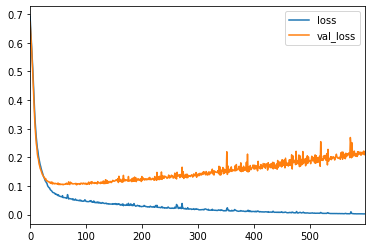

In [24]:
model_loss.plot()

In [25]:
#Early Stoping

In [26]:
model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dense(units=15,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

In [29]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Train on 426 samples, validate on 143 samples
Epoch 1/600
426/426 [==============================] - 1s 3ms/sample - loss: 0.6996 - val_loss: 0.6731
Epoch 2/600
426/426 [==============================] - 0s 123us/sample - loss: 0.6594 - val_loss: 0.6344
Epoch 3/600
426/426 [==============================] - 0s 140us/sample - loss: 0.6233 - val_loss: 0.6010
Epoch 4/600
426/426 [==============================] - 0s 124us/sample - loss: 0.5892 - val_loss: 0.5667
Epoch 5/600
426/426 [==============================] - 0s 140us/sample - loss: 0.5533 - val_loss: 0.5301
Epoch 6/600
426/426 [==============================] - 0s 139us/sample - loss: 0.5162 - val_loss: 0.4907
Epoch 7/600
426/426 [==============================] - 0s 142us/sample - loss: 0.4702 - val_loss: 0.4336
Epoch 8/600
426/426 [==============================] - 0s 168us/sample - loss: 0.4156 - val_loss: 0.3851
Epoch 9/600
426/426 [==============================] - 0s 175us/sample - loss: 0.3696 - val_loss: 0.3402
Epoch 10/60

Epoch 78/600
426/426 [==============================] - 0s 135us/sample - loss: 0.0547 - val_loss: 0.1118
Epoch 79/600
426/426 [==============================] - 0s 121us/sample - loss: 0.0547 - val_loss: 0.1151
Epoch 80/600
426/426 [==============================] - 0s 131us/sample - loss: 0.0556 - val_loss: 0.1111
Epoch 81/600
426/426 [==============================] - 0s 140us/sample - loss: 0.0571 - val_loss: 0.1166
Epoch 82/600
426/426 [==============================] - 0s 114us/sample - loss: 0.0537 - val_loss: 0.1133
Epoch 83/600
426/426 [==============================] - 0s 116us/sample - loss: 0.0555 - val_loss: 0.1141
Epoch 84/600
426/426 [==============================] - 0s 114us/sample - loss: 0.0533 - val_loss: 0.1105
Epoch 85/600
426/426 [==============================] - 0s 114us/sample - loss: 0.0531 - val_loss: 0.1200
Epoch 86/600
426/426 [==============================] - 0s 141us/sample - loss: 0.0570 - val_loss: 0.1162
Epoch 87/600
426/426 [========================

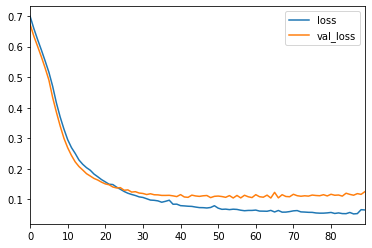

In [30]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [31]:
#Dropout layers
from tensorflow.keras.layers import Dropout

In [32]:
model = Sequential()
model.add(Dense(units=30,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=15,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [33]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Train on 426 samples, validate on 143 samples
Epoch 1/600
426/426 [==============================] - 2s 4ms/sample - loss: 0.6796 - val_loss: 0.6605
Epoch 2/600
426/426 [==============================] - 0s 154us/sample - loss: 0.6606 - val_loss: 0.6438
Epoch 3/600
426/426 [==============================] - 0s 152us/sample - loss: 0.6519 - val_loss: 0.6277
Epoch 4/600
426/426 [==============================] - 0s 156us/sample - loss: 0.6220 - val_loss: 0.6074
Epoch 5/600
426/426 [==============================] - 0s 162us/sample - loss: 0.6048 - val_loss: 0.5819
Epoch 6/600
426/426 [==============================] - 0s 183us/sample - loss: 0.5827 - val_loss: 0.5607
Epoch 7/600
426/426 [==============================] - 0s 150us/sample - loss: 0.5847 - val_loss: 0.5380
Epoch 8/600
426/426 [==============================] - 0s 153us/sample - loss: 0.5547 - val_loss: 0.5152
Epoch 9/600
426/426 [==============================] - 0s 152us/sample - loss: 0.5341 - val_loss: 0.4885
Epoch 10/60

426/426 [==============================] - 0s 195us/sample - loss: 0.1176 - val_loss: 0.0928
Epoch 78/600
426/426 [==============================] - 0s 175us/sample - loss: 0.1241 - val_loss: 0.0858
Epoch 79/600
426/426 [==============================] - 0s 156us/sample - loss: 0.1408 - val_loss: 0.0937
Epoch 80/600
426/426 [==============================] - 0s 158us/sample - loss: 0.1040 - val_loss: 0.0936
Epoch 81/600
426/426 [==============================] - 0s 173us/sample - loss: 0.1430 - val_loss: 0.0863
Epoch 82/600
426/426 [==============================] - 0s 177us/sample - loss: 0.1402 - val_loss: 0.0853
Epoch 83/600
426/426 [==============================] - 0s 162us/sample - loss: 0.1451 - val_loss: 0.1010
Epoch 84/600
426/426 [==============================] - 0s 181us/sample - loss: 0.1214 - val_loss: 0.0862
Epoch 85/600
426/426 [==============================] - 0s 159us/sample - loss: 0.1213 - val_loss: 0.0938
Epoch 86/600
426/426 [==============================] - 0s 

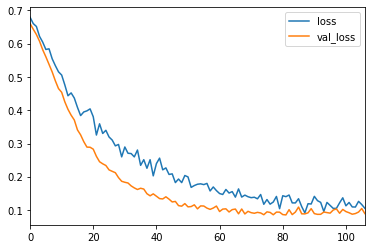

In [34]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [35]:
predictions = model.predict_classes(X_test)

In [36]:
from sklearn.metrics import classification_report,confusion_matrix

In [37]:
# https://en.wikipedia.org/wiki/Precision_and_recall
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        55
           1       0.99      0.98      0.98        88

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



In [38]:
print(confusion_matrix(y_test,predictions))

[[54  1]
 [ 2 86]]
